## ARTIFICIAL INTELLIGENCE
## ASSIGNMENT - 6
## 169085 - ABRAHAM AJUONG KUOL
## 169282 - MATHEWS ZIMBA
## 168653 - STEPHEN NGATARA
## 138547 - DEE EMMANUEL
## 112409 IAN KAHARE GICERO

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



data = pd.read_csv("/Users/dengachiek/Downloads/Mall_Customers.csv")
data.head()



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [5]:
data.shape

(200, 5)

In [6]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [12]:
print("Annual Income Range:", data['Annual Income (k$)'].min(), "to", data['Annual Income (k$)'].max())
print("Spending Score Range:", data['Spending Score (1-100)'].min(), "to", data['Spending Score (1-100)'].max())


Annual Income Range: 15 to 137
Spending Score Range: 1 to 99


In [13]:
print("CustomerID Range:", data['CustomerID'].min(), "to", data['CustomerID'].max())
print("Is CustomerID sequential?", list(data['CustomerID']) == list(range(1, 201)))


CustomerID Range: 1 to 200
Is CustomerID sequential? True


## Let's check for the outliners 

In [20]:
def find_the_outliers(data, columns):
    Q1 = data[columns].quantile(0.25)
    Q3 = data[columns].quantile(0.75)

    # the inter quartile reange
    IQR = Q3 - Q1


    lower_bound = Q1-1.5 * IQR
    upper_bound = Q3-1.5 * IQR

    outliers = data[(data[columns] < lower_bound) | (data[columns] > upper_bound)]

    return outliers, lower_bound, upper_bound

numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in numeric_cols:
    outliers, lower, upper = find_the_outliers(data, col)
    print(f"\n{col}:")
    print(f"  Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
    print(f"  Outliers detected: {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Outlier values: {outliers[col].tolist()}")


Age:
  Lower bound: -1.62, Upper bound: 18.62
  Outliers detected: 196
  Outlier values: [19, 21, 20, 23, 31, 22, 35, 23, 64, 30, 67, 35, 58, 24, 37, 22, 35, 20, 52, 35, 35, 25, 46, 31, 54, 29, 45, 35, 40, 23, 60, 21, 53, 49, 21, 42, 30, 36, 20, 65, 24, 48, 31, 49, 24, 50, 27, 29, 31, 49, 33, 31, 59, 50, 47, 51, 69, 27, 53, 70, 19, 67, 54, 63, 43, 68, 19, 32, 70, 47, 60, 60, 59, 26, 45, 40, 23, 49, 57, 38, 67, 46, 21, 48, 55, 22, 34, 50, 68, 48, 40, 32, 24, 47, 27, 48, 20, 23, 49, 67, 26, 49, 21, 66, 54, 68, 66, 65, 19, 38, 19, 19, 63, 49, 51, 50, 27, 38, 40, 39, 23, 31, 43, 40, 59, 38, 47, 39, 25, 31, 20, 29, 44, 32, 19, 35, 57, 32, 28, 32, 25, 28, 48, 32, 34, 34, 43, 39, 44, 38, 47, 27, 37, 30, 34, 30, 56, 29, 19, 31, 50, 36, 42, 33, 36, 32, 40, 28, 36, 36, 52, 30, 58, 27, 59, 35, 37, 32, 46, 29, 41, 30, 54, 28, 41, 36, 34, 32, 33, 38, 47, 35, 45, 32, 32, 30]

Annual Income (k$):
  Lower bound: -13.25, Upper bound: 23.25
  Outliers detected: 180
  Outlier values: [24, 24, 25, 25, 28

In [23]:

data_cleaned = data.copy()
data_cleaned.columns = df_cleaned.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('-', '_')
print("Standardized Column Names:")
print(df_cleaned.columns.tolist())

data_cleaned['gender'] = df_cleaned['gender'].str.strip()

print("\nGender values after cleaning:")
print(data_cleaned['gender'].value_counts())

print("\nData Types:")
print(data_cleaned.dtypes)

print("\nCleaned Data Sample:")
print(data_cleaned.head(10))

Standardized Column Names:
['customerid', 'gender', 'age', 'annual_income_k$', 'spending_score_1_100']

Gender values after cleaning:
gender
Female    112
Male       88
Name: count, dtype: int64

Data Types:
customerid               int64
gender                  object
age                      int64
annual_income_k$         int64
spending_score_1_100     int64
dtype: object

Cleaned Data Sample:
   customerid  gender  age  annual_income_k$  spending_score_1_100
0           1    Male   19                15                    39
1           2    Male   21                15                    81
2           3  Female   20                16                     6
3           4  Female   23                16                    77
4           5  Female   31                17                    40
5           6  Female   22                17                    76
6           7  Female   35                18                     6
7           8  Female   23                18                    9

In [24]:
data_cleaned

,customerid,gender,age,annual_income_k$,spending_score_1_100
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## Exploratory Data Analyis

In [25]:
print("First 5 rows of the data:")
print(data_cleaned.head())
print()

# Step 4: Check for problems
print("Data shape (rows, columns):", data_cleaned.shape)
print("Missing values:", data_cleaned.isnull().sum().sum())
print("Duplicate rows:", data_cleaned.duplicated().sum())

First 5 rows of the data:
   customerid  gender  age  annual_income_k$  spending_score_1_100
0           1    Male   19                15                    39
1           2    Male   21                15                    81
2           3  Female   20                16                     6
3           4  Female   23                16                    77
4           5  Female   31                17                    40

Data shape (rows, columns): (200, 5)
Missing values: 0
Duplicate rows: 0


In [26]:

data_cleaned.columns = ['customer_id', 'gender', 'age', 'income', 'spending_score']

print("New column names:")
print(data_cleaned.columns.tolist())
print()


print("Average age:", data_cleaned['age'].mean())
print("Average income:", data_cleaned['income'].mean())
print("Average spending score:", data_cleaned['spending_score'].mean())
print()


print("Gender counts:")
print(data_cleaned['gender'].value_counts())

New column names:
['customer_id', 'gender', 'age', 'income', 'spending_score']

Average age: 38.85
Average income: 60.56
Average spending score: 50.2

Gender counts:
gender
Female    112
Male       88
Name: count, dtype: int64


In [27]:

# let create age groups
def get_age_group(age):
    if age <= 25:
        return '18-25'
    elif age <= 35:
        return '26-35'
    elif age <= 45:
        return '36-45'
    elif age <= 55:
        return '46-55'
    else:
        return '56-70'


data_cleaned['age_group'] = data_cleaned['age'].apply(get_age_group)


spending_by_age = data_cleaned.groupby('age_group')['spending_score'].mean()
print("Average spending score by age group:")
print(spending_by_age)
print()


highest_spending_group = spending_by_age.idxmax()
highest_spending_value = spending_by_age.max()
print(f"Highest spending group: {highest_spending_group} with score {highest_spending_value:.1f}")

Average spending score by age group:
age_group
18-25    54.947368
26-35    64.450000
36-45    44.833333
46-55    36.702703
56-70    38.379310
Name: spending_score, dtype: float64

Highest spending group: 26-35 with score 64.5


In [28]:

correlation = data_cleaned['income'].corr(data_cleaned['spending_score'])
print(f"Correlation between income and spending: {correlation:.3f}")
print()

if abs(correlation) < 0.1:
    print("This is VERY LOW - income does NOT predict spending!")
elif abs(correlation) < 0.3:
    print("This is LOW - weak relationship")
elif abs(correlation) < 0.7:
    print("This is MODERATE - some relationship")
else:
    print("This is HIGH - strong relationship")

Correlation between income and spending: 0.010

This is VERY LOW - income does NOT predict spending!


In [29]:

income_median = data_cleaned['income'].median()
spending_median = data_cleaned['spending_score'].median()

print(f"Median income: ${income_median}k")
print(f"Median spending score: {spending_median}")
print()

def get_segment(row):
    high_income = row['income'] >= income_median
    high_spending = row['spending_score'] >= spending_median
    
    if high_income and high_spending:
        return 'Target Customers'
    elif high_income and not high_spending:
        return 'Careless Spenders'
    elif not high_income and high_spending:
        return 'Standard Customers'
    else:
        return 'Careful Spenders'

data_cleaned['segment'] = data_cleaned.apply(get_segment, axis=1)

segment_counts = data_cleaned['segment'].value_counts()
print("Customer segments:")
print(segment_counts)
print()

print("Segment details:")
segment_stats = data_cleaned.groupby('segment')[['age', 'income', 'spending_score']].mean()
print(segment_stats.round(1))

Median income: $61.5k
Median spending score: 50.0

Customer segments:
segment
Standard Customers    52
Careless Spenders     50
Target Customers      50
Careful Spenders      48
Name: count, dtype: int64

Segment details:
                     age  income  spending_score
segment                                         
Careful Spenders    45.1    39.6            33.3
Careless Spenders   40.9    81.5            24.8
Standard Customers  34.8    39.6            65.2
Target Customers    35.0    81.7            76.2


## Now let's draw some graphs for visual look

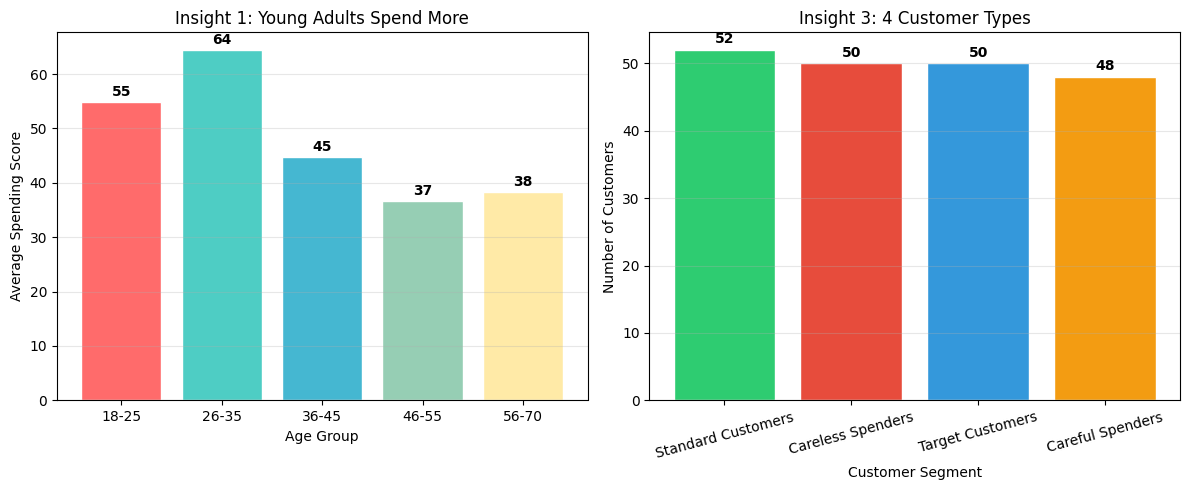

Chart saved!


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

age_groups = ['18-25', '26-35', '36-45', '46-55', '56-70']
spending_values = [spending_by_age[g] for g in age_groups]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

axes[0].bar(age_groups, spending_values, color=colors, edgecolor='white')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Spending Score')
axes[0].set_title('Insight 1: Young Adults Spend More')
axes[0].grid(axis='y', alpha=0.3)


for i, v in enumerate(spending_values):
    axes[0].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold')

segment_names = segment_counts.index.tolist()
segment_values = segment_counts.values.tolist()
segment_colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

axes[1].bar(segment_names, segment_values, color=segment_colors, edgecolor='white')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Insight 3: 4 Customer Types')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(segment_values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("Chart saved!")

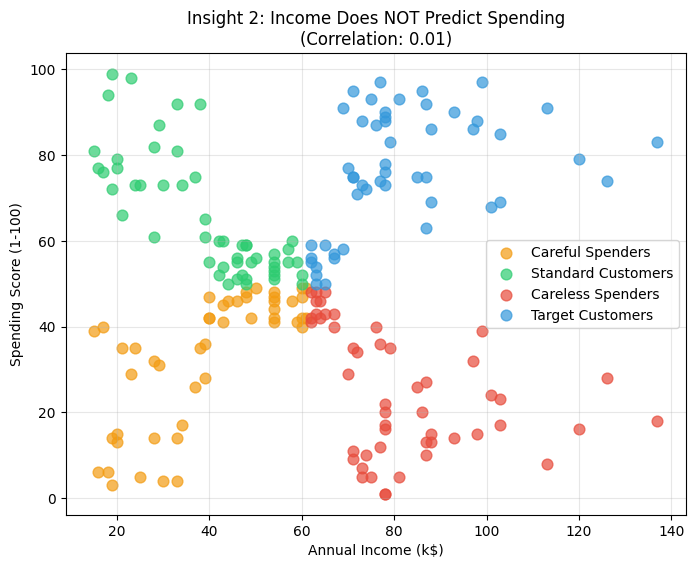

Scatter plot saved!


In [34]:
plt.figure(figsize=(8, 6))

colors_map = {
    'Target Customers': '#3498db',
    'Careless Spenders': '#e74c3c',
    'Standard Customers': '#2ecc71',
    'Careful Spenders': '#f39c12'
}

for segment in data_cleaned['segment'].unique():
    segment_data = data_cleaned[data_cleaned['segment'] == segment]
    plt.scatter(segment_data['income'], segment_data['spending_score'], 
                label=segment, color=colors_map[segment], alpha=0.7, s=60)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Insight 2: Income Does NOT Predict Spending\n(Correlation: 0.01)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()
print("Scatter plot saved!")

In [36]:
pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 1.1 MB/s  0:00:19 eta 0:00:010:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [37]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [38]:
X1 = data_cleaned[['spending_score']]

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

k_values = range(2, 11)
inertia_1 = []
silhouette_1 = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X1_scaled)
    inertia_1.append(kmeans.inertia_)
    silhouette_1.append(silhouette_score(X1_scaled, labels))

results_1 = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertia_1,
    'silhouette_score': silhouette_1
})
results_1

,k,inertia,silhouette_score
0,2,69.109819,0.535192
1,3,20.950959,0.653806
2,4,13.365308,0.601260
3,5,7.754070,0.610347
4,6,5.182503,0.606260
5,7,3.886379,0.598567
6,8,2.958633,0.605507
7,9,2.306638,0.588346
8,10,1.882179,0.603686


## Let's Visualise these

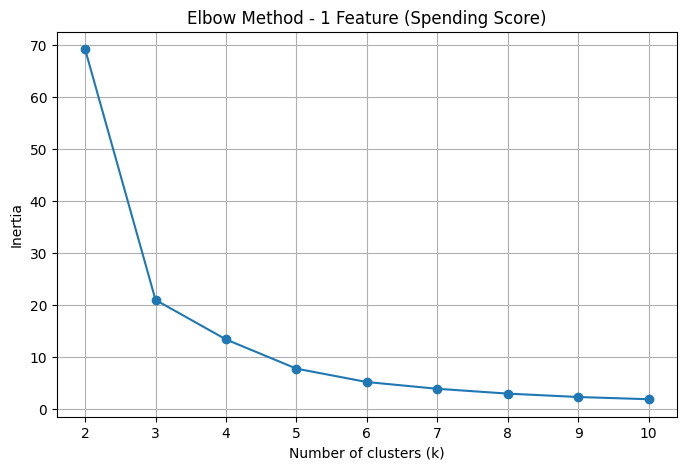

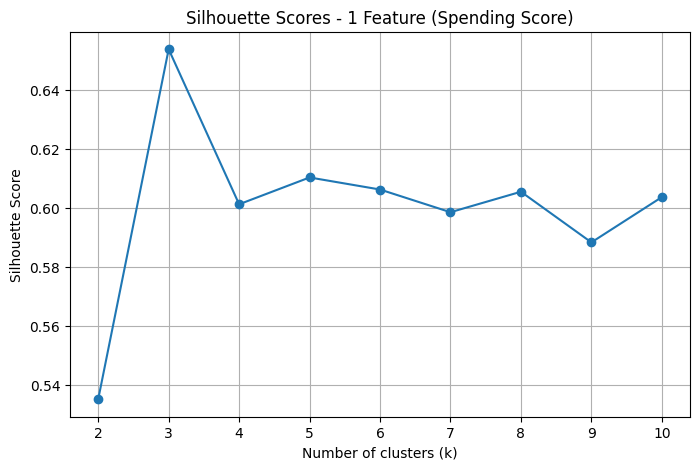

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(results_1['k'], results_1['inertia'], marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - 1 Feature (Spending Score)')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_1['k'], results_1['silhouette_score'], marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores - 1 Feature (Spending Score)')
plt.grid(True)
plt.show()

In [40]:
optimal_k1 = results_1.loc[results_1['silhouette_score'].idxmax(), 'k']
print("Optimal k for 1 feature (based on highest silhouette score):", optimal_k1)

kmeans_1 = KMeans(n_clusters=int(optimal_k1), random_state=42, n_init=10)
data_cleaned['cluster_1feature'] = kmeans_1.fit_predict(X1_scaled)
data_cleaned[['spending_score', 'cluster_1feature']].head()

Optimal k for 1 feature (based on highest silhouette score): 3


,spending_score,cluster_1feature
0,39,1
1,81,0
2,6,2
3,77,0
4,40,1


## 3b

In [41]:
X2 = data_cleaned[['income', 'spending_score']]

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

inertia_2 = []
silhouette_2 = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X2_scaled)
    inertia_2.append(kmeans.inertia_)
    silhouette_2.append(silhouette_score(X2_scaled, labels))

results_2 = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertia_2,
    'silhouette_score': silhouette_2
})
results_2

,k,inertia,silhouette_score
0,2,269.691012,0.321271
1,3,157.704008,0.466585
2,4,108.921317,0.493907
3,5,65.568408,0.554657
4,6,55.057348,0.539880
5,7,44.864756,0.528149
6,8,37.228188,0.455215
7,9,32.392268,0.457085
8,10,29.981898,0.443171


## let' take visuals for this 

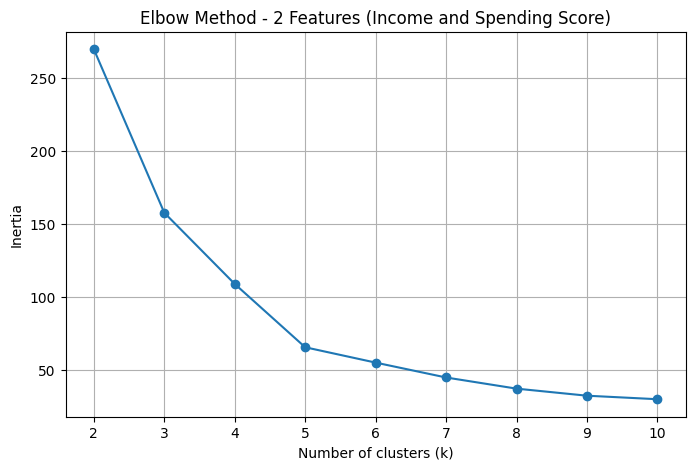

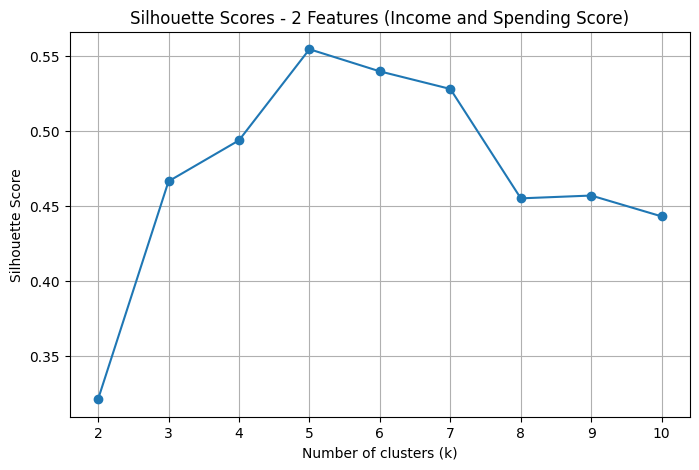

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(results_2['k'], results_2['inertia'], marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - 2 Features (Income and Spending Score)')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_2['k'], results_2['silhouette_score'], marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores - 2 Features (Income and Spending Score)')
plt.grid(True)
plt.show()

In [43]:
optimal_k2 = results_2.loc[results_2['silhouette_score'].idxmax(), 'k']
print("Optimal k for 2 features (based on highest silhouette score):", optimal_k2)

kmeans_2 = KMeans(n_clusters=int(optimal_k2), random_state=42, n_init=10)
data_cleaned['cluster_2features'] = kmeans_2.fit_predict(X2_scaled)
data_cleaned[['income', 'spending_score', 'cluster_2features']].head()

Optimal k for 2 features (based on highest silhouette score): 5


,income,spending_score,cluster_2features
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


In [44]:
cluster_2_summary = data_cleaned.groupby('cluster_2features')[['income', 'spending_score', 'age']].mean().round(2)
cluster_2_counts = data_cleaned['cluster_2features'].value_counts().sort_index()

print("Cluster sizes:\n")
print(cluster_2_counts)
print("\nCluster mean profile:\n")
cluster_2_summary

Cluster sizes:

cluster_2features
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster mean profile:



,income,spending_score,age
cluster_2features,,,
0,55.30,49.52,42.72
1,86.54,82.13,32.69
2,25.73,79.36,25.27
3,88.20,17.11,41.11
4,26.30,20.91,45.22


## Compare the two 3a and 3b

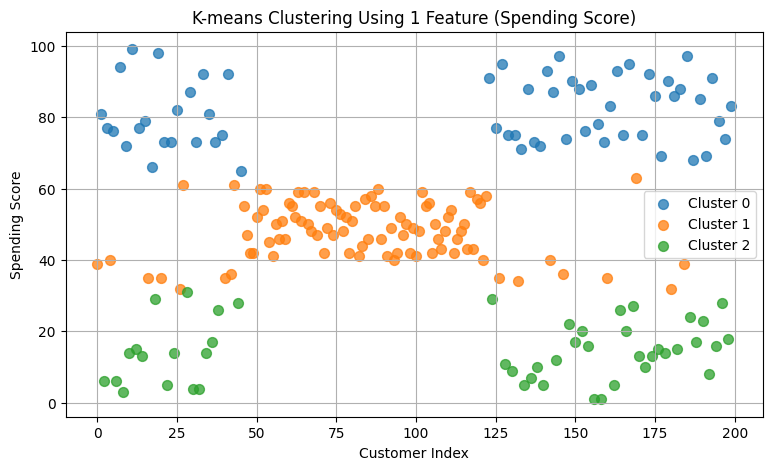

In [45]:
plt.figure(figsize=(9, 5))
for cluster in sorted(data_cleaned['cluster_1feature'].unique()):
    subset = data_cleaned[data_cleaned['cluster_1feature'] == cluster]
    plt.scatter(
        subset.index,
        subset['spending_score'],
        label=f'Cluster {cluster}',
        s=50,
        alpha=0.75
    )

plt.xlabel('Customer Index')
plt.ylabel('Spending Score')
plt.title('K-means Clustering Using 1 Feature (Spending Score)')
plt.legend()
plt.grid(True)
plt.show()

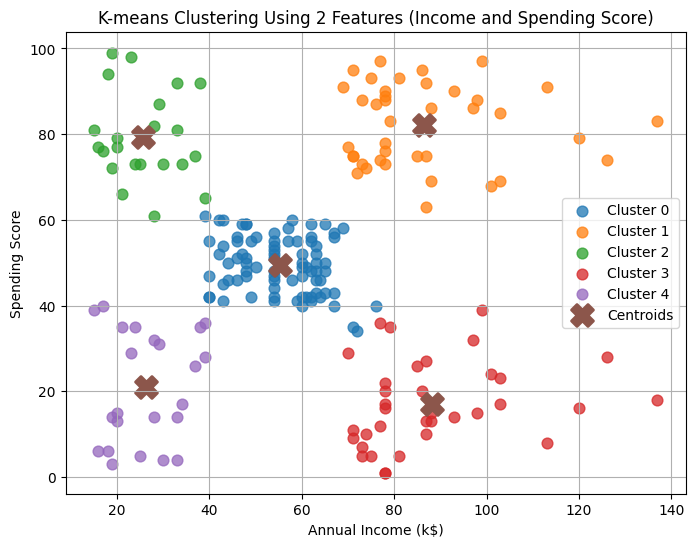

In [46]:
plt.figure(figsize=(8, 6))
for cluster in sorted(data_cleaned['cluster_2features'].unique()):
    subset = data_cleaned[data_cleaned['cluster_2features'] == cluster]
    plt.scatter(
        subset['income'],
        subset['spending_score'],
        label=f'Cluster {cluster}',
        s=60,
        alpha=0.75
    )
centers_scaled = kmeans_2.cluster_centers_
centers = scaler2.inverse_transform(centers_scaled)
plt.scatter(
    centers[:, 0], centers[:, 1],
    marker='X', s=250, linewidths=2, label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('K-means Clustering Using 2 Features (Income and Spending Score)')
plt.legend()
plt.grid(True)
plt.show()